# Домашнее задание: детекция и распознавание номерных знаков

# Панин Иван Михайлович

In [5]:
!pip -q install ultralytics tqdm scikit-learn matplotlib pillow

In [3]:
from pathlib import Path
import csv
import json
import os
import random
import shutil
import zipfile
import xml.etree.ElementTree as ET

import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

from ultralytics import YOLO

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False


PROJECT_DIR = Path.cwd()
DOWN_DIR = PROJECT_DIR / 'down'
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
DATASETS_DIR = PROJECT_DIR / 'datasets'

for path in [DOWN_DIR, DATA_DIR, OUTPUT_DIR, DATASETS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DETECTION_ZIP = DOWN_DIR / 'number_car_detect.zip'
OCR_ZIP = DOWN_DIR / 'autoriaNumberplateOcrRu.zip'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PROJECT_DIR:', PROJECT_DIR)
print('DOWN_DIR:', DOWN_DIR)
print('device:', device)
print('Detection zip exists:', DETECTION_ZIP.exists(), DETECTION_ZIP)
print('OCR zip exists:', OCR_ZIP.exists(), OCR_ZIP)

PROJECT_DIR: /content
DOWN_DIR: /content/down
device: cuda
Detection zip exists: True /content/down/number_car_detect.zip
OCR zip exists: True /content/down/autoriaNumberplateOcrRu.zip


##  Распаковка локальных архивов



In [4]:
def extract_zip_once(zip_path: Path, out_dir: Path) -> None:
    marker = out_dir / '.extracted'
    if marker.exists():
        print(f'Already extracted: {out_dir}')
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(out_dir)
    marker.write_text('ok', encoding='utf-8')
    print(f'Extracted {zip_path.name} -> {out_dir}')


def count_images(root: Path) -> int:
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    return sum(1 for p in root.rglob('*') if p.suffix.lower() in exts)


def find_dir_with_most_images(root: Path) -> Path:
    candidates = [root]
    if root.exists():
        candidates.extend(p for p in root.rglob('*') if p.is_dir())
    return max(candidates, key=count_images)


extract_zip_once(DETECTION_ZIP, DATA_DIR / 'number_car_detect')
if OCR_ZIP.exists():
    extract_zip_once(OCR_ZIP, DATA_DIR / 'OCR')
else:
    print('OCR archive is missing. Put autoriaNumberplateOcrRu.zip into down before CRNN training.')

DETECTION_IMAGES_ROOT = find_dir_with_most_images(DATA_DIR / 'number_car_detect')
print('Detection images root:', DETECTION_IMAGES_ROOT)
print('Detection image count:', count_images(DETECTION_IMAGES_ROOT))

Extracted number_car_detect.zip -> /content/data/number_car_detect
Extracted autoriaNumberplateOcrRu.zip -> /content/data/OCR
Detection images root: /content/data/number_car_detect
Detection image count: 368


##  Загрузка ручной разметки для детекции


In [10]:
LABELS_ROOT = DATA_DIR / 'detection_labels'
LABELS_ROOT.mkdir(parents=True, exist_ok=True)

def import_annotation_zip(zip_path: Path, labels_root: Path) -> int:
    copied = 0
    with zipfile.ZipFile(zip_path) as archive:
        xml_members = [
            name for name in archive.namelist()
            if name.lower().endswith('.xml') and '/annotations/' in ('/' + name.lower())
        ]
        txt_members = [
            name for name in archive.namelist()
            if name.lower().endswith('.txt') and not name.lower().endswith('classes.txt')
        ]
        for member in xml_members + txt_members:
            target = labels_root / Path(member).name
            with archive.open(member) as src, target.open('wb') as dst:
                shutil.copyfileobj(src, dst)
            copied += 1
    return copied



for zip_path in sorted(DOWN_DIR.glob('*.zip')):
    if zip_path.name in {'number_car_detect.zip', 'autoriaNumberplateOcrRu.zip'}:
        continue
    copied = import_annotation_zip(zip_path, LABELS_ROOT)
    if copied:
        print(f'Imported {copied} annotation files from {zip_path.name}')

label_count = len(list(LABELS_ROOT.rglob('*.txt'))) + len(list(LABELS_ROOT.rglob('*.xml')))
print('Label files found:', label_count)

if label_count == 0:
    print(
        'No detection labels found. Add YOLO .txt or Pascal VOC .xml labels to data/detection_labels, '
        'or put a local annotation archive such as down/car-plate-detection.zip into down and rerun this cell.'
    )

Imported 433 annotation files from car-plate-detection.zip
Label files found: 433


##  Подготовка YOLO-датасета `train / val / test` 70/15/15

In [11]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def iter_images(root: Path) -> list[Path]:
    return sorted(p for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)


def yolo_from_xml(xml_path: Path) -> list[str]:
    root = ET.parse(xml_path).getroot()
    size = root.find('size')
    width = float(size.findtext('width', '0'))
    height = float(size.findtext('height', '0'))
    rows = []
    for obj in root.findall('object'):
        box = obj.find('bndbox')
        if box is None:
            continue
        xmin = float(box.findtext('xmin', '0'))
        ymin = float(box.findtext('ymin', '0'))
        xmax = float(box.findtext('xmax', '0'))
        ymax = float(box.findtext('ymax', '0'))
        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height
        rows.append(f'0 {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}')
    return rows


def validate_yolo_rows(rows, label_path: Path) -> list[str]:
    clean = []
    for line_no, row in enumerate(rows, start=1):
        row = row.strip()
        if not row:
            continue
        parts = row.split()
        if len(parts) != 5:
            raise ValueError(f'{label_path}:{line_no}: expected 5 fields, got {len(parts)}')
        class_id = int(float(parts[0]))
        values = [float(v) for v in parts[1:]]
        clean.append('0 ' + ' '.join(f'{v:.6f}' for v in values))
    return clean


def find_annotation(image_path: Path, labels_root: Path) -> Path | None:
    candidates = [
        labels_root / f'{image_path.stem}.txt',
        labels_root / f'{image_path.stem}.xml',
        image_path.with_suffix('.txt'),
        image_path.with_suffix('.xml'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def read_label(image_path: Path, labels_root: Path) -> list[str] | None:
    label_path = find_annotation(image_path, labels_root)
    if label_path is None:
        return None
    if label_path.suffix.lower() == '.xml':
        rows = yolo_from_xml(label_path)
    else:
        rows = label_path.read_text(encoding='utf-8').splitlines()
    return validate_yolo_rows(rows, label_path)


def write_yolo_data_yaml(output_root: Path) -> Path:
    yaml_path = output_root / 'data.yaml'
    yaml_path.write_text(
        '\n'.join([
            f'path: {output_root.resolve().as_posix()}',
            'train: images/train',
            'val: images/val',
            'test: images/test',
            'names:',
            '  0: license_plate',
            '',
        ]),
        encoding='utf-8',
    )
    return yaml_path


def prepare_detection_dataset(images_root: Path, labels_root: Path, output_root: Path, annotated_fraction=1.0) -> Path:
    images = iter_images(images_root)
    items = []
    missing = 0
    for image_path in images:
        rows = read_label(image_path, labels_root)
        if rows:
            items.append((image_path, rows))
        else:
            missing += 1
    random.shuffle(items)
    if 0 < annotated_fraction < 1:
        items = items[:max(1, int(round(len(items) * annotated_fraction)))]
    if output_root.exists():
        shutil.rmtree(output_root)
    n = len(items)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)
    splits = {
        'train': items[:n_train],
        'val': items[n_train:n_train + n_val],
        'test': items[n_train + n_val:],
    }
    for split, split_items in splits.items():
        image_dir = output_root / 'images' / split
        label_dir = output_root / 'labels' / split
        image_dir.mkdir(parents=True, exist_ok=True)
        label_dir.mkdir(parents=True, exist_ok=True)
        for image_path, rows in split_items:
            shutil.copy2(image_path, image_dir / image_path.name)
            (label_dir / f'{image_path.stem}.txt').write_text('\n'.join(rows) + '\n', encoding='utf-8')
    data_yaml = write_yolo_data_yaml(output_root)
    print(f'Images found: {len(images)}')
    print(f'Annotated images used: {n}')
    print(f'Missing labels skipped: {missing}')
    for split, split_items in splits.items():
        print(f'{split}: {len(split_items)}')
    print('YOLO config:', data_yaml)
    return data_yaml


DETECTION_DATASET_ROOT = DATASETS_DIR / 'license_plate_detection'
DETECTION_DATA_YAML = prepare_detection_dataset(
    DETECTION_IMAGES_ROOT,
    LABELS_ROOT,
    DETECTION_DATASET_ROOT,
    annotated_fraction=1.0,
)

Images found: 368
Annotated images used: 346
Missing labels skipped: 22
train: 242
val: 51
test: 53
YOLO config: /content/datasets/license_plate_detection/data.yaml


##  Визуальная проверка разметки



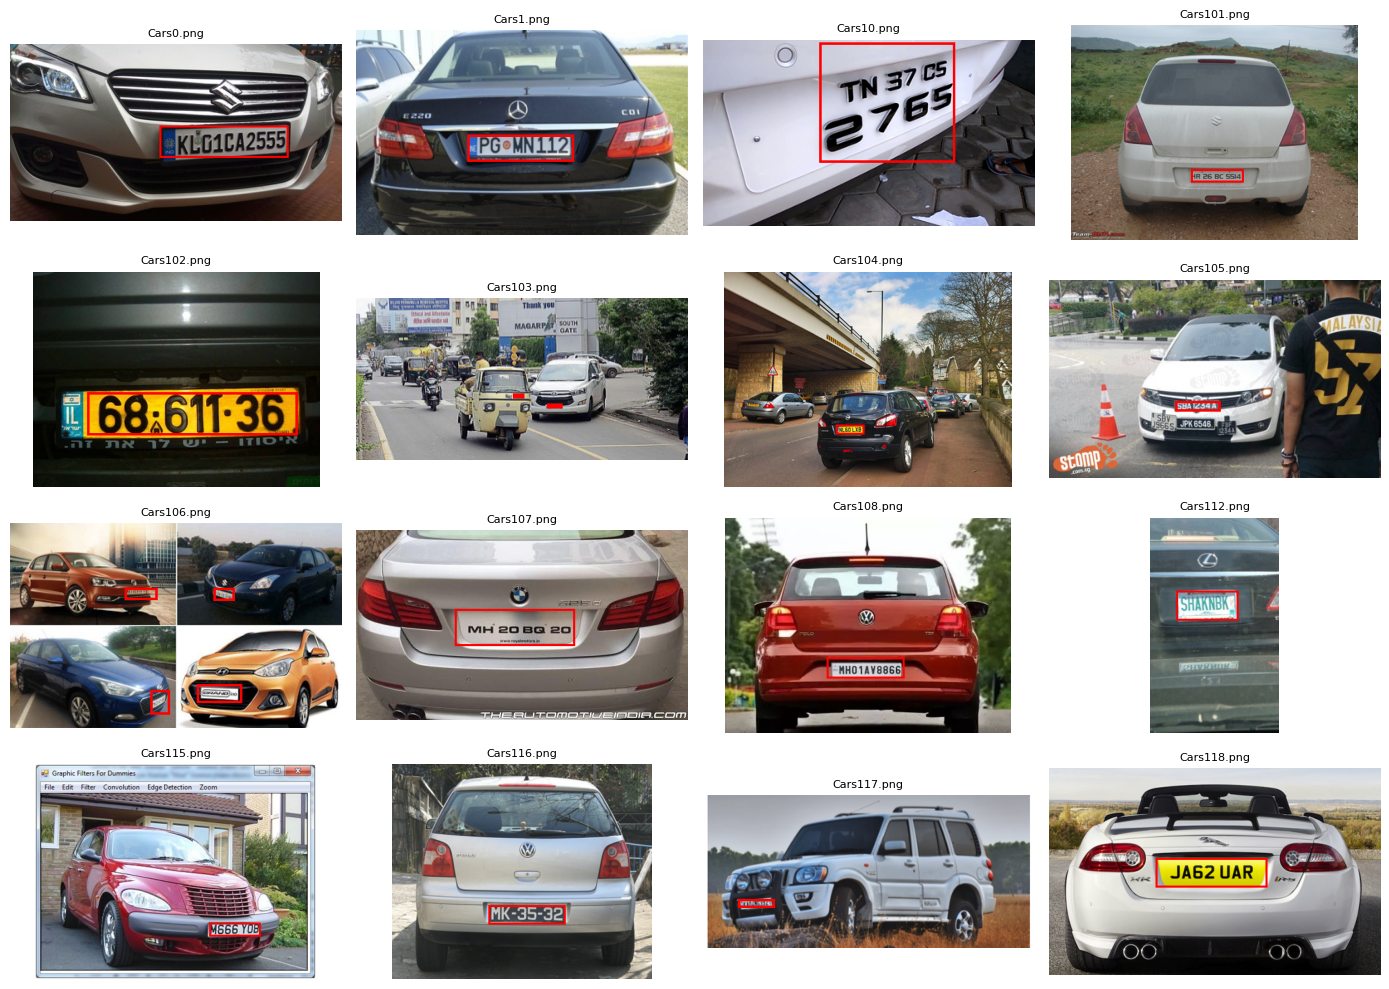

In [12]:
def draw_yolo_boxes(image_path: Path, label_path: Path, max_size=(480, 320)) -> Image.Image:
    image = Image.open(image_path).convert('RGB')
    original_w, original_h = image.size
    image.thumbnail(max_size)
    sx, sy = image.width / original_w, image.height / original_h
    draw = ImageDraw.Draw(image)
    if label_path.exists():
        for row in label_path.read_text(encoding='utf-8').splitlines():
            parts = row.split()
            if len(parts) != 5:
                continue
            _, xc, yc, bw, bh = map(float, parts)
            x1 = (xc * original_w - bw * original_w / 2) * sx
            y1 = (yc * original_h - bh * original_h / 2) * sy
            x2 = (xc * original_w + bw * original_w / 2) * sx
            y2 = (yc * original_h + bh * original_h / 2) * sy
            draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=3)
    return image


sample_images = iter_images(DETECTION_DATASET_ROOT / 'images' / 'train')[:16]
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, image_path in zip(axes.ravel(), sample_images):
    label_path = DETECTION_DATASET_ROOT / 'labels' / 'train' / f'{image_path.stem}.txt'
    ax.imshow(draw_yolo_boxes(image_path, label_path))
    ax.set_title(image_path.name, fontsize=8)
    ax.axis('off')
for ax in axes.ravel()[len(sample_images):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

##  Обучение YOLO-детектора и расчет метрик `mAP@0.5`, `mAP@0.5:0.95`, `Precision`, `Recall`.

In [13]:
DETECTOR_EPOCHS = 80
DETECTOR_BATCH = 16
DETECTOR_IMGSZ = 640
DETECTOR_PROJECT = OUTPUT_DIR / 'detector'
DETECTOR_NAME = 'license_plate_yolov8n'


def metric_to_float(value) -> float:
    array = np.asarray(value, dtype=float)
    return float(np.nanmean(array)) if array.size else float('nan')


detector = YOLO('yolov8n.pt')
detector.train(
    data=str(DETECTION_DATA_YAML),
    epochs=DETECTOR_EPOCHS,
    imgsz=DETECTOR_IMGSZ,
    batch=DETECTOR_BATCH,
    project=str(DETECTOR_PROJECT),
    name=DETECTOR_NAME,
    pretrained=True,
)

detector_metrics_raw = detector.val(data=str(DETECTION_DATA_YAML), split='test')
detector_metrics = {
    'mAP@0.5': metric_to_float(detector_metrics_raw.box.map50),
    'mAP@0.5:0.95': metric_to_float(detector_metrics_raw.box.map),
    'precision': metric_to_float(detector_metrics_raw.box.p),
    'recall': metric_to_float(detector_metrics_raw.box.r),
}
metrics_path = DETECTOR_PROJECT / DETECTOR_NAME / 'test_metrics.json'
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text(json.dumps(detector_metrics, indent=2), encoding='utf-8')
detector_metrics

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/license_plate_detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=

{'mAP@0.5': 0.8731949925837281,
 'mAP@0.5:0.95': 0.4814245680322496,
 'precision': 0.863531947516587,
 'recall': 0.8703703703703703}

##  Проверка детектора на изображении из интернета



image 1/1 /content/down/Singer_Chamois_Coupe_license_plate_1967.jpg: 448x640 1 license_plate, 6.6ms
Speed: 2.6ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-3


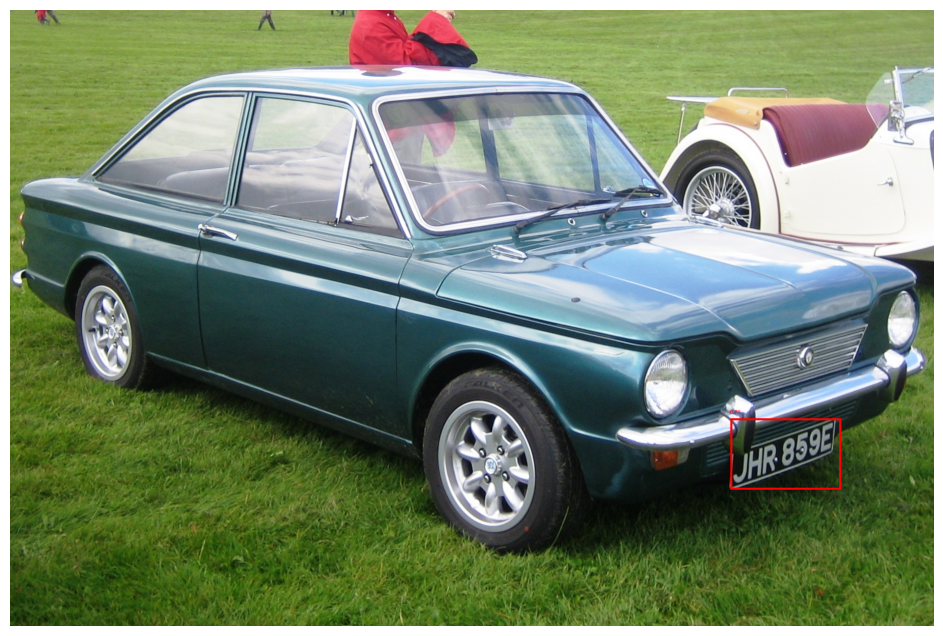

Test image: /content/down/Singer_Chamois_Coupe_license_plate_1967.jpg
Detector weights: /content/outputs/detector/license_plate_yolov8n/weights/best.pt


In [19]:
EXTERNAL_IMAGE_PATH = DOWN_DIR / 'Singer_Chamois_Coupe_license_plate_1967.jpg'

trained_detector_path = DETECTOR_PROJECT / DETECTOR_NAME / 'weights' / 'best.pt'
external_results = YOLO(str(trained_detector_path)).predict(
    source=str(EXTERNAL_IMAGE_PATH),
    conf=0.25,
    save=True,
)

result_image = Image.open(EXTERNAL_IMAGE_PATH).convert('RGB')
draw = ImageDraw.Draw(result_image)

boxes = external_results[0].boxes
if len(boxes) == 0:
    print('Номерной знак не найден.')
else:
    for xyxy, conf in zip(boxes.xyxy, boxes.conf):
        x1, y1, x2, y2 = [int(v) for v in xyxy.detach().cpu().tolist()]
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=4)
        draw.text((x1, max(0, y1 - 18)), f'{float(conf):.2f}', fill=(255, 0, 0))

plt.figure(figsize=(12, 8))
plt.imshow(result_image)
plt.axis('off')
plt.show()

print('Test image:', EXTERNAL_IMAGE_PATH)
print('Detector weights:', trained_detector_path)

## Датасет и алфавит для CRNN


In [20]:
DEFAULT_ALPHABET = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'


class Alphabet:
    def __init__(self, chars=DEFAULT_ALPHABET, blank_idx=0):
        self.chars = chars
        self.blank_idx = blank_idx
        self.char2idx = {char: idx + 1 for idx, char in enumerate(chars)}
        self.idx2char = {idx + 1: char for idx, char in enumerate(chars)}
        self.vocab_size = len(chars) + 1

    def encode(self, text: str) -> list[int]:
        return [self.char2idx[c] for c in str(text).upper() if c in self.char2idx]

    def decode(self, sequence: torch.Tensor) -> str:
        prev = None
        out = []
        for raw_idx in sequence.detach().cpu().tolist():
            idx = int(raw_idx)
            if idx != self.blank_idx and idx != prev and idx in self.idx2char:
                out.append(self.idx2char[idx])
            prev = idx
        return ''.join(out)


def resolve_ocr_root(root: Path) -> Path:
    candidates = [root]
    candidates.extend(p for p in root.rglob('*') if p.is_dir())
    for candidate in candidates:
        if (candidate / 'train' / 'ann').exists() and (candidate / 'train' / 'img').exists():
            return candidate
    raise FileNotFoundError('Could not find OCR root with train/ann and train/img.')


def find_ocr_image(img_dir: Path, name: str) -> Path:
  for suffix in ('.png', '.jpg', '.jpeg', '.bmp', '.webp'):
    candidate = img_dir / f'{name}{suffix}'
  return candidate


class NumberplateOCRDataset(Dataset):
    def __init__(self, root: Path, split: str, alphabet: Alphabet, transform=None, max_samples=None):
        self.root = root
        self.split = split
        self.alphabet = alphabet
        self.transform = transform
        self.ann_paths = sorted((root / split / 'ann').glob('*.json'))
        if max_samples is not None:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    def __getitem__(self, idx):
        ann_path = self.ann_paths[idx]
        data = json.loads(ann_path.read_text(encoding='utf-8'))
        name = data['name']
        text = str(data.get('description', '')).upper()
        image_path = find_ocr_image(self.root / self.split / 'img', name)
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(self.alphabet.encode(text), dtype=torch.long)
        return image, label, text


def collate_fn(batch):
    batch = [item for item in batch if len(item[1]) > 0]
    images = torch.stack([item[0] for item in batch], dim=0)
    labels = [item[1] for item in batch]
    texts = [item[2] for item in batch]
    targets = torch.cat(labels, dim=0)
    target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
    return images, targets, target_lengths, texts


OCR_ROOT = resolve_ocr_root(DATA_DIR / 'OCR')
print('OCR_ROOT:', OCR_ROOT)
print('train annotations:', len(list((OCR_ROOT / 'train' / 'ann').glob('*.json'))))
print('test annotations:', len(list((OCR_ROOT / 'test' / 'ann').glob('*.json'))))

OCR_ROOT: /content/data/OCR/autoriaNumberplateOcrRu
train annotations: 49382
test annotations: 2845


## Модель CRNN и метрики распознавания


In [21]:
class CRNN(nn.Module):
    def __init__(self, num_classes, input_channels=1, width_mult=1.0, hidden_size=256, lstm_layers=2, dropout=0.1):
        super().__init__()

        def ch(value):
            return max(16, int(round(value * width_mult)))

        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, ch(64), 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(ch(64), ch(128), 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(ch(128), ch(256), 3, padding=1), nn.BatchNorm2d(ch(256)), nn.ReLU(inplace=True),
            nn.Conv2d(ch(256), ch(256), 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1)),
            nn.Conv2d(ch(256), ch(512), 3, padding=1), nn.BatchNorm2d(ch(512)), nn.ReLU(inplace=True),
            nn.Conv2d(ch(512), ch(512), 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 1), padding=(0, 1)),
            nn.Conv2d(ch(512), ch(512), 2), nn.BatchNorm2d(ch(512)), nn.ReLU(inplace=True),
        )
        self.rnn = nn.LSTM(
            input_size=ch(512),
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, images):
        features = self.cnn(images)
        features = features.mean(dim=2)
        features = features.permute(2, 0, 1)
        sequence, _ = self.rnn(features)
        return self.classifier(sequence).log_softmax(dim=2)


def make_transform(img_height, img_width, augment=False):
    transforms = [T.Grayscale(num_output_channels=1)]
    if augment:
        transforms.extend([
            T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25)], p=0.6),
            T.RandomAffine(degrees=3, translate=(0.03, 0.05), scale=(0.95, 1.05), shear=2),
        ])
    transforms.extend([
        T.Resize((img_height, img_width)),
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,)),
    ])
    return T.Compose(transforms)


def levenshtein(a: str, b: str) -> int:
    if len(a) < len(b):
        return levenshtein(b, a)
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        current = [i]
        for j, char_b in enumerate(b, start=1):
            current.append(min(current[j - 1] + 1, previous[j] + 1, previous[j - 1] + (char_a != char_b)))
        previous = current
    return previous[-1]


def evaluate_crnn(model, loader, alphabet, device):
    model.eval()
    total_distance = 0
    total_chars = 0
    exact = 0
    total = 0
    samples = []
    with torch.no_grad():
        for images, _, _, texts in loader:
            images = images.to(device)
            logits = model(images)
            predictions = logits.permute(1, 0, 2).argmax(dim=2)
            for idx, gt in enumerate(texts):
                pred = alphabet.decode(predictions[idx])
                samples.append({'gt': gt, 'pred': pred})
                total += 1
                exact += int(pred == gt)
                total_distance += levenshtein(gt, pred)
                total_chars += max(1, len(gt))
    return {
        'cer': total_distance / max(1, total_chars),
        'exact_accuracy': exact / max(1, total),
        'samples': samples,
    }

## Обучение CRNN: baseline и эксперименты



In [26]:
EXPERIMENTS = {
    'baseline_fast': {
        'img_height': 32, 'img_width': 128, 'batch_size': 64, 'lr': 1e-3,
        'optimizer': 'adam', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128,
        'scheduler': 'none', 'augment': False,
    },
    'larger_input_fast': {
        'img_height': 32, 'img_width': 160, 'batch_size': 64, 'lr': 1e-3,
        'optimizer': 'adam', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128,
        'scheduler': 'none', 'augment': False,
    },
    'augment_scheduler_fast': {
        'img_height': 32, 'img_width': 160, 'batch_size': 64, 'lr': 7e-4,
        'optimizer': 'adamw', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128,
        'scheduler': 'cosine', 'augment': True,
    },
}


MAX_TRAIN_SAMPLES = 15000
MAX_TEST_SAMPLES = 1000

for name, config in EXPERIMENTS.items():
    print(name, config)

baseline_fast {'img_height': 32, 'img_width': 128, 'batch_size': 64, 'lr': 0.001, 'optimizer': 'adam', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128, 'scheduler': 'none', 'augment': False}
larger_input_fast {'img_height': 32, 'img_width': 160, 'batch_size': 64, 'lr': 0.001, 'optimizer': 'adam', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128, 'scheduler': 'none', 'augment': False}
augment_scheduler_fast {'img_height': 32, 'img_width': 160, 'batch_size': 64, 'lr': 0.0007, 'optimizer': 'adamw', 'epochs': 10, 'width_mult': 0.5, 'hidden_size': 128, 'scheduler': 'cosine', 'augment': True}


##  Запуск CRNN-экспериментов и таблица CER


In [27]:
def make_optimizer(name, model, lr):
    if name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr)
    raise ValueError(f'Unknown optimizer: {name}')


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []
    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)
        logits = model(images)
        time_steps, batch_size, _ = logits.size()
        input_lengths = torch.full((batch_size,), time_steps, dtype=torch.long, device=device)
        loss = criterion(logits, targets, input_lengths, target_lengths)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else float('nan')


def run_crnn_experiment(name, config):
    alphabet = Alphabet(DEFAULT_ALPHABET)
    out_dir = OUTPUT_DIR / 'crnn' / name
    out_dir.mkdir(parents=True, exist_ok=True)

    train_ds = NumberplateOCRDataset(
        OCR_ROOT, 'train', alphabet,
        make_transform(config['img_height'], config['img_width'], config['augment']),
        max_samples=MAX_TRAIN_SAMPLES,
    )
    test_ds = NumberplateOCRDataset(
        OCR_ROOT, 'test', alphabet,
        make_transform(config['img_height'], config['img_width'], False),
        max_samples=MAX_TEST_SAMPLES,
    )
    train_loader = DataLoader(
        train_ds, batch_size=config['batch_size'], shuffle=True,
        num_workers=2, collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_ds, batch_size=config['batch_size'], shuffle=False,
        num_workers=2, collate_fn=collate_fn,
    )

    model = CRNN(alphabet.vocab_size, width_mult=config['width_mult'], hidden_size=config['hidden_size']).to(device)
    criterion = nn.CTCLoss(blank=alphabet.blank_idx, zero_infinity=True)
    optimizer = make_optimizer(config['optimizer'], model, config['lr'])
    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])
        if config['scheduler'] == 'cosine'
        else None
    )

    history = []
    best_cer = float('inf')
    for epoch in range(1, config['epochs'] + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        metrics = evaluate_crnn(model, test_loader, alphabet, device)
        if scheduler is not None:
            scheduler.step()
        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'cer': metrics['cer'],
            'exact_accuracy': metrics['exact_accuracy'],
        }
        history.append(row)
        print(f"[{name}] epoch={epoch:03d} loss={train_loss:.4f} CER={metrics['cer']:.4f} exact={metrics['exact_accuracy']:.4f}")
        if metrics['cer'] < best_cer:
            best_cer = metrics['cer']
            torch.save(
                {
                    'model_state': model.state_dict(),
                    'alphabet': alphabet.chars,
                    'config': config,
                    'model_kwargs': {
                        'num_classes': alphabet.vocab_size,
                        'width_mult': config['width_mult'],
                        'hidden_size': config['hidden_size'],
                    },
                },
                out_dir / 'best.pt',
            )
            with (out_dir / 'predictions.csv').open('w', encoding='utf-8', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=['gt', 'pred'])
                writer.writeheader()
                writer.writerows(metrics['samples'])

    result = {
        'experiment': name,
        'config': config,
        'best_cer': min(item['cer'] for item in history),
        'best_exact_accuracy': max(item['exact_accuracy'] for item in history),
        'history': history,
    }
    (out_dir / 'metrics.json').write_text(json.dumps(result, indent=2), encoding='utf-8')
    (out_dir / 'alphabet.json').write_text(json.dumps({'alphabet': alphabet.chars}, indent=2), encoding='utf-8')
    return result


CRNN_RESULTS = []
for exp_name, exp_config in EXPERIMENTS.items():
    CRNN_RESULTS.append(run_crnn_experiment(exp_name, dict(exp_config)))

(OUTPUT_DIR / 'crnn').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'crnn' / 'summary.json').write_text(json.dumps(CRNN_RESULTS, indent=2), encoding='utf-8')

best_crnn = min(CRNN_RESULTS, key=lambda item: item['best_cer'])
print('\nBest CRNN:', best_crnn['experiment'])
print('Best CER:', best_crnn['best_cer'])
print('Best exact accuracy:', best_crnn['best_exact_accuracy'])
print('\nExperiment table:')
for item in CRNN_RESULTS:
    print(f"{item['experiment']:18s} CER={item['best_cer']:.4f} exact={item['best_exact_accuracy']:.4f}")

[baseline_fast] epoch=001 loss=2.9876 CER=0.8684 exact=0.0000
[baseline_fast] epoch=002 loss=1.9933 CER=0.5568 exact=0.0000
[baseline_fast] epoch=003 loss=0.6213 CER=0.0360 exact=0.7470
[baseline_fast] epoch=004 loss=0.0818 CER=0.0084 exact=0.9410
[baseline_fast] epoch=005 loss=0.0295 CER=0.0058 exact=0.9590
[baseline_fast] epoch=006 loss=0.0170 CER=0.0063 exact=0.9580
[baseline_fast] epoch=007 loss=0.0145 CER=0.0057 exact=0.9580
[baseline_fast] epoch=008 loss=0.0075 CER=0.0034 exact=0.9770
[baseline_fast] epoch=009 loss=0.0044 CER=0.0027 exact=0.9790
[baseline_fast] epoch=010 loss=0.0115 CER=0.0053 exact=0.9630
[larger_input_fast] epoch=001 loss=3.0086 CER=0.8299 exact=0.0000
[larger_input_fast] epoch=002 loss=1.4475 CER=0.2087 exact=0.0860
[larger_input_fast] epoch=003 loss=0.3371 CER=0.0254 exact=0.8380
[larger_input_fast] epoch=004 loss=0.0611 CER=0.0078 exact=0.9450
[larger_input_fast] epoch=005 loss=0.0248 CER=0.0061 exact=0.9590
[larger_input_fast] epoch=006 loss=0.0171 CER=0.00

## Финальный end-to-end пайплайн



PIPELINE_IMAGE: /content/data/number_car_detect/number_car_detect/Cars1.png
Predicted text: P084H112
Expected text:  PGMN112
Correct: False
{'text': 'P084H112', 'box': (127, 123, 267, 162), 'output': '/content/outputs/pipeline_result.jpg'}


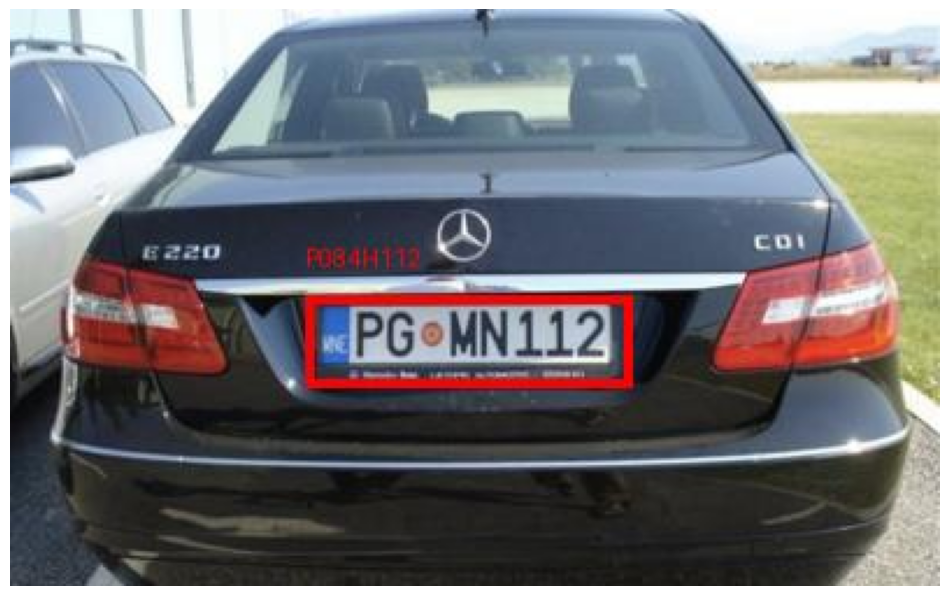

In [47]:
def load_crnn_checkpoint(checkpoint_path: Path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    alphabet = Alphabet(checkpoint['alphabet'])
    config = checkpoint['config']
    model = CRNN(**checkpoint['model_kwargs']).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    transform = make_transform(config['img_height'], config['img_width'], False)
    return model, alphabet, transform


def recognize_crop(model, alphabet, transform, crop: Image.Image) -> str:
    tensor = transform(crop).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        sequence = logits.permute(1, 0, 2).argmax(dim=2)[0]
    return alphabet.decode(sequence)


def padded_box(box, width, height, padding=0.04):
    x1, y1, x2, y2 = [float(v) for v in box]
    pad_x = (x2 - x1) * padding
    pad_y = (y2 - y1) * padding
    return (
        max(0, int(round(x1 - pad_x))),
        max(0, int(round(y1 - pad_y))),
        min(width, int(round(x2 + pad_x))),
        min(height, int(round(y2 + pad_y))),
    )


def run_pipeline(image_path: Path, detector_weights: Path, crnn_checkpoint: Path, output_path: Path):
    image = Image.open(image_path).convert('RGB')
    detector = YOLO(str(detector_weights))
    crnn_model, alphabet, transform = load_crnn_checkpoint(crnn_checkpoint)

    detections = detector.predict(source=str(image_path), conf=0.25, verbose=False)
    if not detections or len(detections[0].boxes) == 0:
        raise RuntimeError('No license plate detected')
    boxes = detections[0].boxes
    best_idx = int(torch.argmax(boxes.conf).item())
    crop_box = padded_box(boxes.xyxy[best_idx].detach().cpu().tolist(), image.width, image.height)
    crop = image.crop(crop_box)
    text = recognize_crop(crnn_model, alphabet, transform, crop)

    rendered = image.copy()
    draw = ImageDraw.Draw(rendered)
    draw.rectangle(crop_box, outline=(255, 0, 0), width=4)
    draw.text((crop_box[0], max(0, crop_box[1] - 22)), text, fill=(255, 0, 0))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    rendered.save(output_path)
    return {'text': text, 'box': crop_box, 'output': str(output_path)}


cars0_candidates = list((DATA_DIR / 'number_car_detect').rglob('Cars1.png'))


PIPELINE_IMAGE = cars0_candidates[0]
print('PIPELINE_IMAGE:', PIPELINE_IMAGE)

EXPECTED_TEXT = 'PGMN112'
DETECTOR_WEIGHTS = DETECTOR_PROJECT / DETECTOR_NAME / 'weights' / 'best.pt'
CRNN_CHECKPOINT = OUTPUT_DIR / 'crnn' / best_crnn['experiment'] / 'best.pt'
PIPELINE_OUTPUT = OUTPUT_DIR / 'pipeline_result.jpg'

pipeline_result = run_pipeline(PIPELINE_IMAGE, DETECTOR_WEIGHTS, CRNN_CHECKPOINT, PIPELINE_OUTPUT)

print('Predicted text:', pipeline_result['text'])
print('Expected text: ', EXPECTED_TEXT)
print('Correct:', pipeline_result['text'] == EXPECTED_TEXT)
print(pipeline_result)

plt.figure(figsize=(12, 8))
plt.imshow(Image.open(PIPELINE_OUTPUT))
plt.axis('off')
plt.show()